# ReTReK route scoring

This tutorial scores finished synthesis routes with the ReTReK CD, AS, RD, and ST reaction heuristics. Scoring happens **after** planning and consumes detached `Route` objects: it does not walk the MCTS tree or change the search score.

## The post-processing boundary

The data flow is `tree.routes()` → `list[Route]` → `RetrekRouteScorer.rank(routes)`. Each `Route` carries ordered `Step` objects, the exact product disconnected by each step, its rule ID, and the availability verdict needed by ASScore.

In [1]:
from pathlib import Path

import pandas as pd
from IPython.display import Markdown, SVG, display

from synplan.chem.reaction.routes.io import read_routes_json
from synplan.chem.reaction.routes.quality.retrek import (
    ASRouteScorer,
    CDRouteScorer,
    RDRouteScorer,
    STRouteScorer,
    RetrekRouteScorer,
    RetrekRouteScoringConfig,
)
from synplan.chem.reaction.routes.route import Route
from synplan.utils.loading import download_preset, load_reaction_rules
from chython import depict_settings

depict_settings(aam=False)

## Load the reaction rules

The serialized steps carry integer policy-rule IDs. Load the same ordered reaction-rule collection used by the `synplanner-gps` preset so each ID indexes the applicable canonical retro reactor.

In [2]:
repo_checkout = Path("tutorials").is_dir()
data_root = Path("tutorials/synplan_data") if repo_checkout else Path("synplan_data")

paths = download_preset("synplanner-gps", save_to=data_root)
reaction_rules_path = paths["reaction_rules"]
reaction_rules = load_reaction_rules(reaction_rules_path)

print(f"Loaded {len(reaction_rules):,} reaction rules")


Loaded 11,235 reaction rules


## Restore two detached Route objects

The compact fixture contains two routes selected from `new_retrek_routes.json`:

- route **0** contains one ring disconnection;
- route **1** contains no ring disconnection.

`Route.from_json` restores the step graph, rule IDs, and stock verdict without needing the original MCTS tree.

In [3]:
fixture_path = Path("data/retrek_route_examples.json")

route_trees = read_routes_json(fixture_path)
routes_by_id = {
    int(route_id): Route.from_json(route_tree)
    for route_id, route_tree in route_trees.items()
}
assert set(routes_by_id) == {0, 1}

selected_route_ids = (0, 1)
routes = [routes_by_id[route_id] for route_id in selected_route_ids]
routes


[<Route -: 6 steps, solved, no score>, <Route -: 5 steps, solved, no score>]

## Configure all four scores

The aggregate enables CD, AS, RD, and ST with relative weights 5.0, 0.5, 2.0, and 2.0. Each step is the normalized weighted mean

`(5·CD + 0.5·AS + 2·RD + 2·ST) / 9.5`

when all four component scores are available. The route score is the arithmetic mean of its step scores.

In [4]:
config = RetrekRouteScoringConfig(
    enabled_scores=("cd", "as", "rd", "st"),
    weights={"cd": 5.0, "as": 0.5, "rd": 2.0, "st": 2.0},
)
scorer = RetrekRouteScorer(config, reaction_rules=reaction_rules)
component_scorers = {
    "CDScore": CDRouteScorer(),
    "ASScore": ASRouteScorer(),
    "RDScore": RDRouteScorer(),
    "STScore": STRouteScorer(reaction_rules=reaction_rules),
}


## Route-level aggregation

Let $K_j$ be the reaction-level aggregate for step $j$. For a route containing $M$ reaction steps, the route score is their arithmetic mean:

$$
K_{\mathrm{route}}
= \frac{1}{M}\sum_{j=1}^{M} K_j
= \frac{1}{M}\sum_{j=1}^{M}
\left(
\frac{\sum_{i \in A_j} w_i s_{ij}}
     {\sum_{i \in A_j} w_i}
\right).
$$

Here, $s_{ij}$ is component score $i$ for reaction $j$, $w_i$ is its weight, and $A_j$ contains the scores available for that reaction. Every reaction step contributes equally to the final route score.


In [5]:
def route_breakdown(route: Route) -> pd.DataFrame:
    component_scores = {
        name: component.step_scores(route)
        for name, component in component_scorers.items()
    }
    aggregate_scores = scorer.step_scores(route)
    return pd.DataFrame(
        [
            {
                "step": index + 1,
                "rule_id": step.origin.rule_id,
                "CDScore": component_scores["CDScore"][index],
                "ASScore": component_scores["ASScore"][index],
                "RDScore": component_scores["RDScore"][index],
                "STScore": component_scores["STScore"][index],
                "aggregate": aggregate_scores[index],
            }
            for index, step in enumerate(route.steps)
        ]
    ).round({"CDScore": 3, "aggregate": 3})


## ASScore for one or more precursors

ASScore is the fraction of reaction precursors that are available:

`ASScore = number of available precursors / number of precursors`.

Consequently, a one-precursor step scores `1.0` when that precursor is available and `0.0` when it is unavailable. In these examples, route 0 step 4 and route 1 step 3 each have one available precursor and therefore score `1.0`.

## Compare a ring-disconnection route with an all-zero route

The tables report the calculated component scores and the drawings use the detached `Route` objects directly.

### Route route 0  
ReTReK score: **0.4005**

,step,rule_id,CDScore,ASScore,RDScore,STScore,aggregate
0,1,310,0.400000,1.0,0.0,0.5,0.368421
1,2,345,0.333333,0.5,1.0,1.0,0.622807
2,3,465,0.090909,0.5,0.0,1.0,0.284689
3,4,3,0.000000,1.0,0.0,1.0,0.263158
4,5,7,0.666667,0.5,0.0,1.0,0.587719
5,6,856,0.125000,0.0,0.0,1.0,0.276316


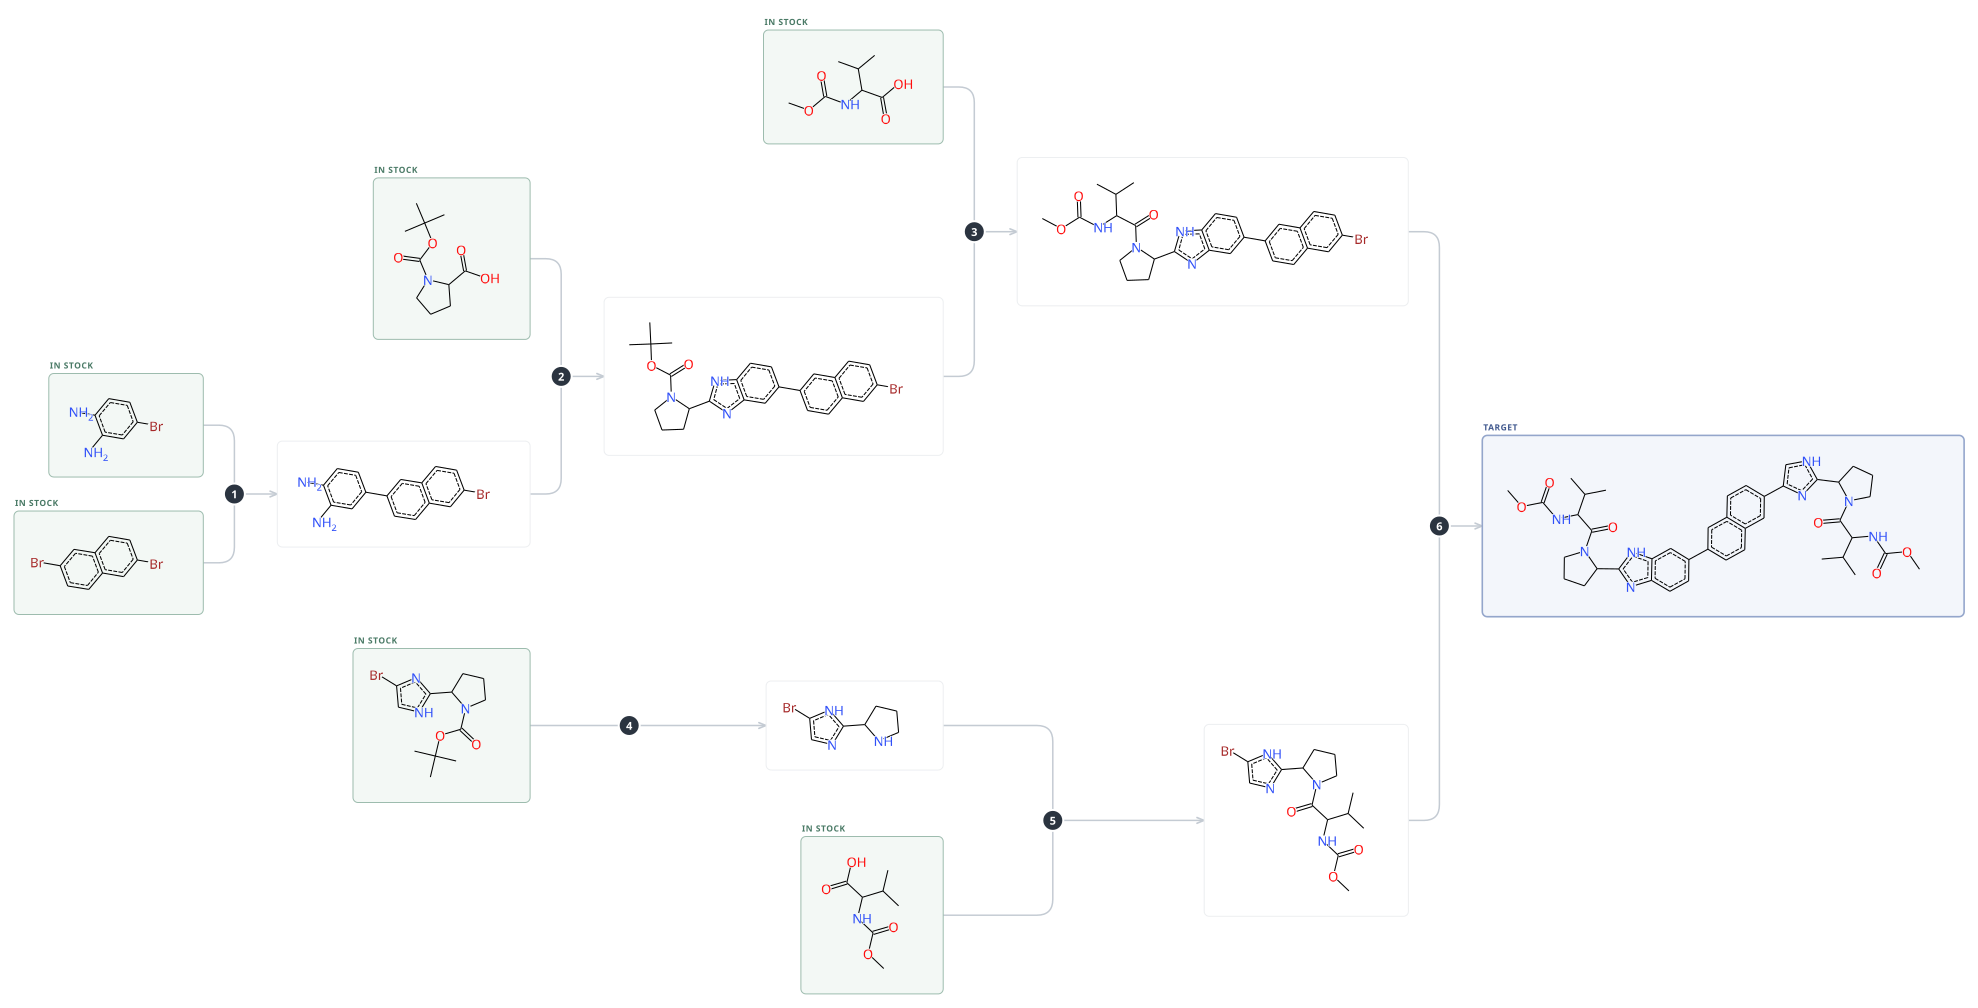

### Route route 1  
ReTReK score: **0.3315**

,step,rule_id,CDScore,ASScore,RDScore,STScore,aggregate
0,1,310,0.166667,1.0,0.0,0.5,0.245614
1,2,465,0.090909,0.5,0.0,1.0,0.284689
2,3,3,0.000000,1.0,0.0,1.0,0.263158
3,4,7,0.666667,0.5,0.0,1.0,0.587719
4,5,856,0.125000,0.0,0.0,1.0,0.276316


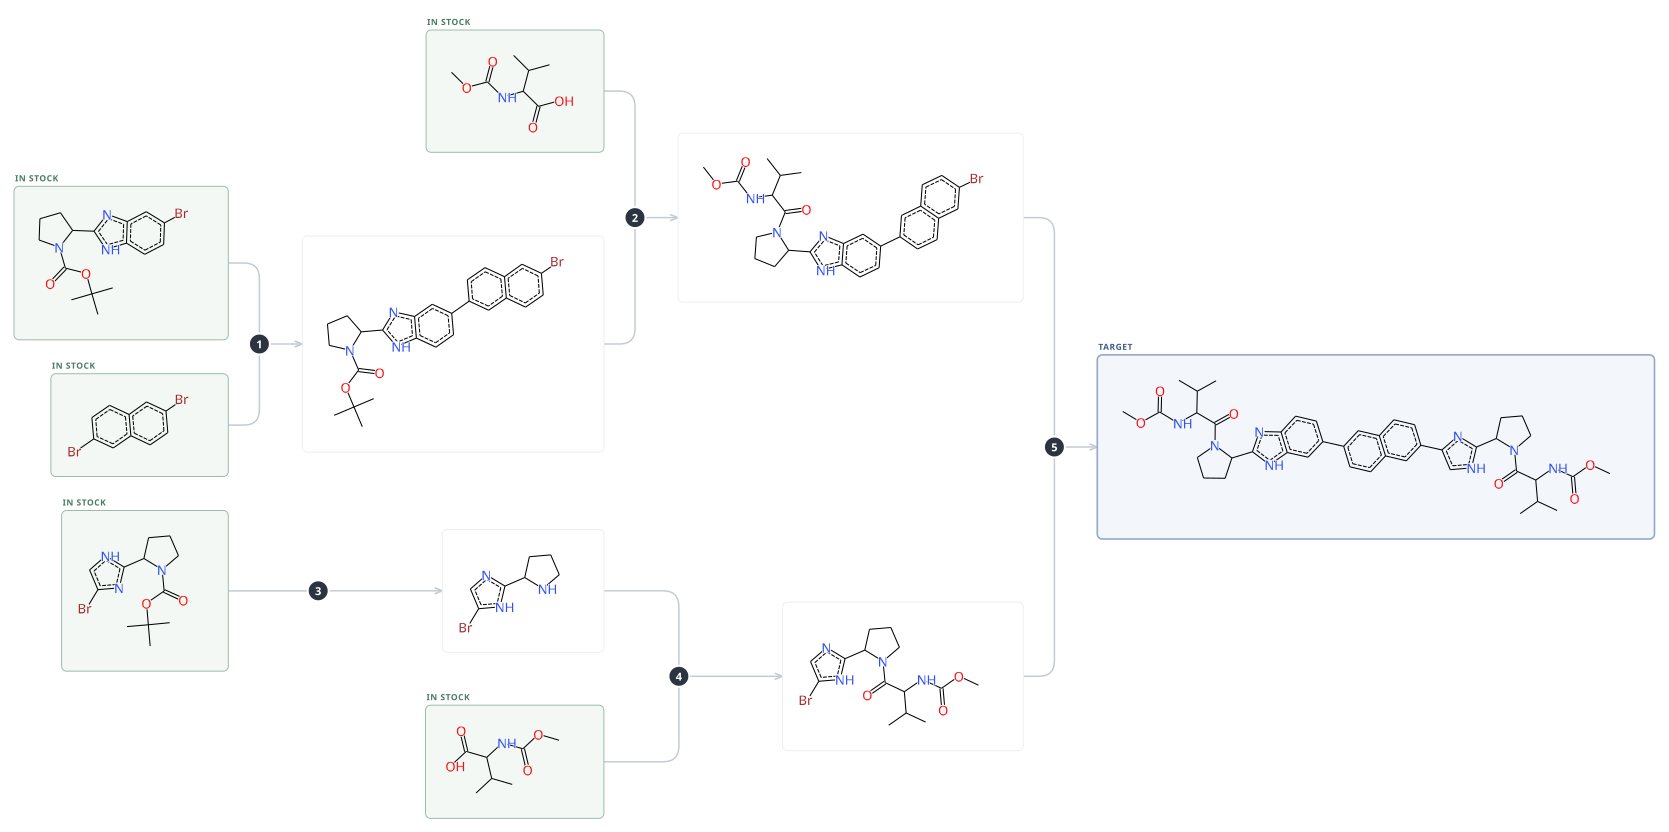

In [20]:
breakdowns = {}

for route_id in selected_route_ids:
    route = routes_by_id[route_id]
    breakdown = route_breakdown(route)
    breakdowns[route_id] = breakdown

    display(
        Markdown(
            f"### Route route {route_id}  \n"
            f"ReTReK score: **{scorer.score(route):.4f}**"
        )
    )
    display(breakdown)
    display(SVG(route.svg()))


In [7]:
summary = pd.DataFrame(
    [
        {
            "route_id": route_id,
            "steps": len(routes_by_id[route_id]),
            "RDScore pattern": tuple(breakdowns[route_id]["RDScore"]),
            "ReTReK score": scorer.score(routes_by_id[route_id]),
        }
        for route_id in selected_route_ids
    ]
)
summary


,route_id,steps,RDScore pattern,ReTReK score
0,0,6,"(0.0, 1.0, 0.0, 0.0, 0.0, 0.0)",0.400518
1,1,5,"(0.0, 0.0, 0.0, 0.0, 0.0)",0.331499
